# 01 — Visual Perception & Design Principles
**Goal:** Learn how humans actually read a chart so you can design for the eye,
not against it.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('versions')
print(' numpy     ', np.__version__)
print(' pandas    ', pd.__version__)
print(' matplotlib', plt.matplotlib.__version__)

versions
 numpy      2.5.0
 pandas     3.0.3
 matplotlib 3.11.0


## 1. Why theory comes before syntax

A chart is a **decision aid**, not a picture. Your job is to map a question to a
visual encoding that the human visual system can decode in milliseconds.

Two facts drive almost every design decision in this course:

1. People decode position and length **most accurately**.
2. People decode color hue **least accurately** (color is great for category,
   bad for quantity).

Cleveland & McGill (1984) ranked encodings by perceptual accuracy:

```
Most accurate  ─────────────────────────────►  Least accurate
position     length      angle      area
  ↓            ↓          ↓          ↓
darker/lighter  color hue  saturation  shape
```

**Rule of thumb:** the most important quantitative variable should sit on the
position or length channel, not on color.

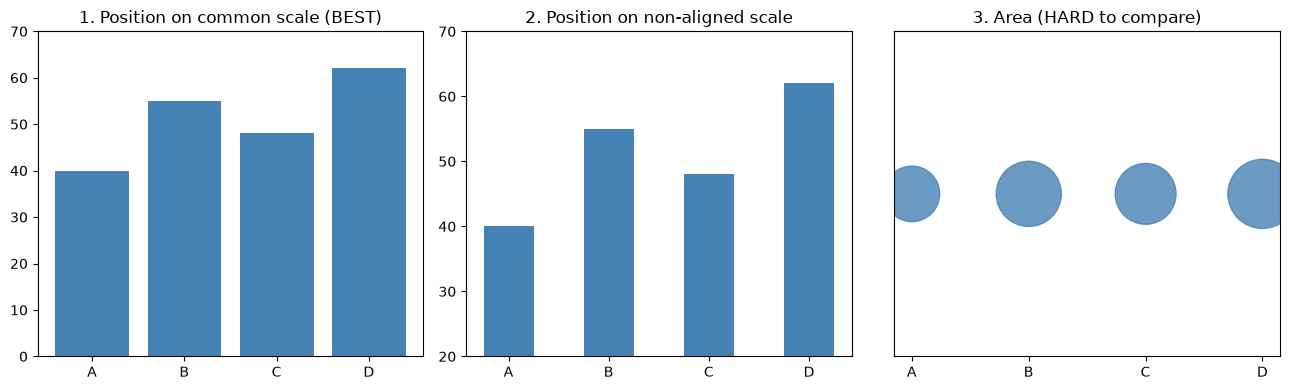

In [2]:
np.random.seed(0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

categories = ['A', 'B', 'C', 'D']
values     = [40, 55, 48, 62]

axes[0].bar(categories, values, color='steelblue')
axes[0].set_title('1. Position on common scale (BEST)')
axes[0].set_ylim(0, 70)

axes[1].bar(categories, values, color='steelblue', width=0.5)
axes[1].set_title('2. Position on non-aligned scale')
axes[1].set_ylim(20, 70)

axes[2].scatter(categories, [0]*4, s=[v*40 for v in values],
                c='steelblue', alpha=0.8)
axes[2].set_title('3. Area (HARD to compare)')
axes[2].set_ylim(-1, 1); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

**The same numbers, three different encodings.** Notice that panel 1 is trivially
readable, panel 2 is harder (axis starts at 20), and panel 3 makes you think
hard to rank the categories. Same data, very different cognitive load.

## 2. Preattentive attributes — the 200 ms test

Some visual features are detected **before** focused attention. Ware (2012)
calls these *preattentive attributes*:

| Attribute | Strongest use case |
|---|---|
| **Color hue** | Categorical distinction |
| **Color saturation** | Order / intensity (e.g. heatmaps) |
| **Length / position** | Quantitative comparison |
| **Size (area)** | Quantitative (use sparingly) |
| **Orientation** | Categorical (limited categories) |
| **Shape** | Categorical distinction |
| **Motion** | Pulling attention to change |

If you can make the *one* thing you want the reader to see pop out
preattentively, the chart succeeds.

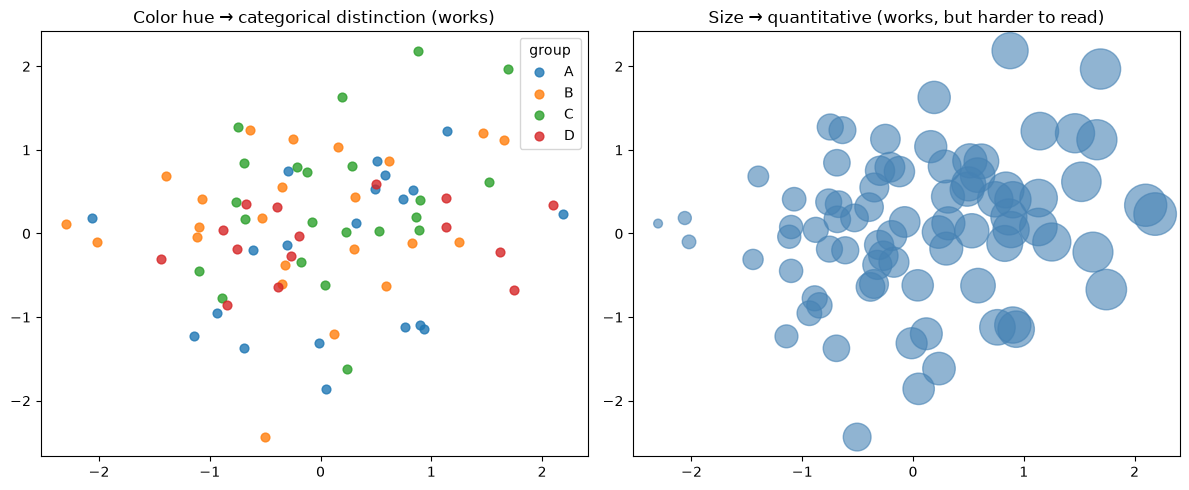

In [3]:
np.random.seed(1)
n = 80
x = np.random.randn(n)
y = np.random.randn(n)
groups = np.random.choice(['A', 'B', 'C', 'D'], n)
df = pd.DataFrame({'x': x, 'y': y, 'group': groups})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.tab10.colors[:4]
for g, c in zip(['A', 'B', 'C', 'D'], colors):
    sub = df[df.group == g]
    axes[0].scatter(sub.x, sub.y, color=c, label=g, s=40, alpha=0.8)
axes[0].legend(title='group')
axes[0].set_title('Color hue → categorical distinction (works)')

sizes = (df.x - df.x.min()) * 200 + 40
axes[1].scatter(df.x, df.y, s=sizes, c='steelblue', alpha=0.6)
axes[1].set_title('Size → quantitative (works, but harder to read)')

plt.tight_layout()
plt.show()

## 3. Gestalt principles

Four principles that explain almost every "clean chart" you have ever seen:

- **Proximity** — things close together feel related.
- **Similarity** — things that look alike feel related.
- **Common region** — a shared background groups items.
- **Continuity** — the eye follows smooth lines.

These show up everywhere: small multiples (proximity), consistent colors per
series (similarity), callout boxes (common region), smooth trend lines
(continuity).

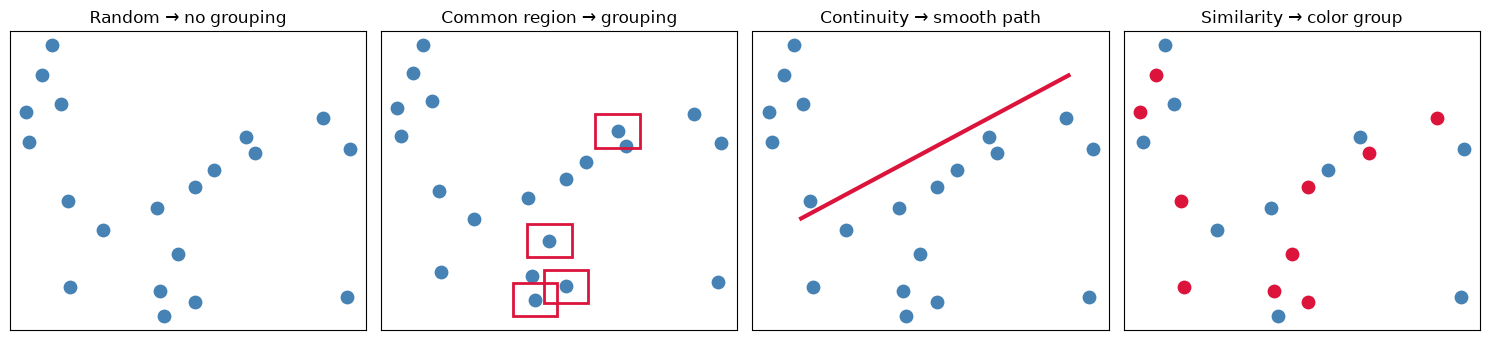

In [4]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
np.random.seed(2)
pts = np.random.rand(20, 2)

axes[0].scatter(pts[:, 0], pts[:, 1], s=80, c='steelblue')
axes[0].set_title('Random → no grouping')

axes[1].scatter(pts[:, 0], pts[:, 1], s=80, c='steelblue')
for i in range(0, 20, 5):
    axes[1].add_patch(Rectangle((pts[i, 0]-0.05, pts[i, 1]-0.05),
                                0.1, 0.1, fill=False, lw=2, ec='crimson'))
axes[1].set_title('Common region → grouping')

axes[2].scatter(pts[:, 0], pts[:, 1], s=80, c='steelblue')
axes[2].plot([0.2, 0.8], [0.3, 0.7], color='crimson', lw=3)
axes[2].set_title('Continuity → smooth path')

axes[3].scatter(pts[:10, 0], pts[:10, 1], s=80, c='steelblue')
axes[3].scatter(pts[10:, 0], pts[10:, 1], s=80, c='crimson')
axes[3].set_title('Similarity → color group')

for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. The chart-selection decision tree

Match the *question* to the *visual*:

| Question | Best chart |
|---|---|
| How is one variable distributed? | Histogram, KDE, box, violin, ECDF |
| How do two variables relate? | Scatter, hexbin, 2D density |
| How does a quantity change over time? | Line, area, slope, candlestick |
| How do categories compare? | Bar, dot, lollipop, slope |
| How do parts make a whole? | Stacked bar, treemap, sunburst, mosaic |
| Where is something on a map? | Choropleth, point map, hex map |
| How do many variables relate? | Heatmap, parallel coords, small multiples, bubble |
| What flows where? | Sankey, chord, network |

Avoid: pie charts for >3 categories, 3D effects, dual y-axes (almost always
fixable), and rainbow color scales on quantitative data.

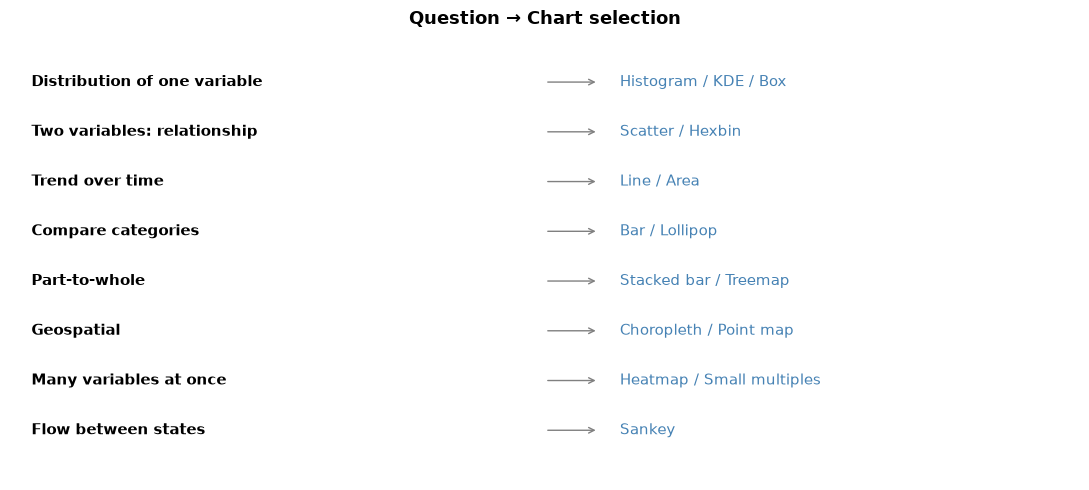

In [5]:
questions = [
("Distribution of one variable",       "Histogram / KDE / Box"),
("Two variables: relationship",       "Scatter / Hexbin"),
("Trend over time",                   "Line / Area"),
("Compare categories",                "Bar / Lollipop"),
("Part-to-whole",                     "Stacked bar / Treemap"),
("Geospatial",                        "Choropleth / Point map"),
("Many variables at once",            "Heatmap / Small multiples"),
("Flow between states",               "Sankey"),
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')
ax.axis([0, 1, 0, 1])
for i, (q, c) in enumerate(questions):
    y = 1 - (i + 1) / (len(questions) + 1)
    ax.text(0.02, y, q, fontsize=11, va='center', weight='bold')
    ax.annotate('', xy=(0.55, y), xytext=(0.50, y),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text(0.57, y, c, fontsize=11, va='center', color='steelblue')
ax.set_title('Question → Chart selection', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 5. The data-ink ratio (Tufte)

Tufte's data-ink ratio:

```
data-ink ratio = ink used to display data / total ink used
```

The goal is **not** to maximize it. The goal is to remove ink that does not
carry information: redundant gridlines, heavy borders, decorative chartjunk,
shading, 3D effects. What remains should be the data, the labels, and the
minimum frame needed to read them.

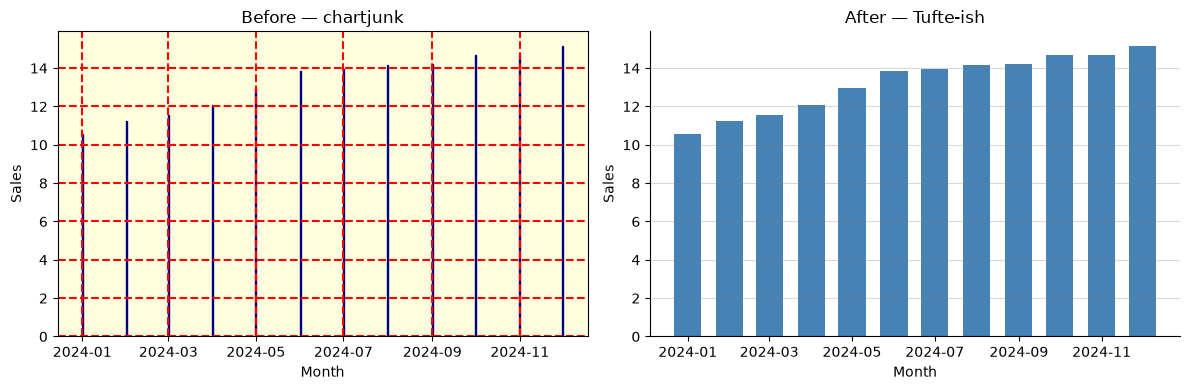

In [6]:
np.random.seed(3)
months = pd.date_range('2024-01-01', periods=12, freq='MS')
sales  = (np.random.rand(12).cumsum() + 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(months, sales, color='skyblue', edgecolor='navy')
axes[0].set_facecolor('lightyellow')
axes[0].grid(True, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Before — chartjunk')

axes[1].bar(months, sales, color='steelblue', width=20)
axes[1].set_title('After — Tufte-ish')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', color='gray', alpha=0.3)

for ax in axes:
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

## 6. Lying with charts — common traps

These are the misuses you must defend against, both as author and reader:

1. **Truncated y-axis** — exaggerates small differences.
2. **Aspect ratio abuse** — a wide chart makes a trend look flat, a tall chart
   makes it look steep (Cleveland's *banking to 45°* rule).
3. **Dual y-axes** — visually equates two unrelated series.
4. **Area as quantity** — humans underestimate area; bars are safer.
5. **Unsorted categorical axis** — random order hides the ranking.
6. **Rainbow colormap** — implies boundaries that are not in the data.
7. **Cherry-picked time window** — zoom hides the context.

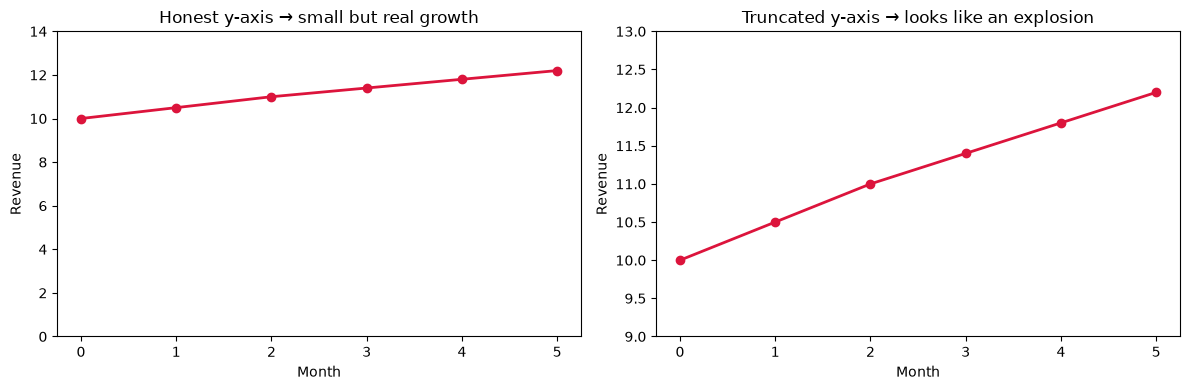

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(6)
y = [10, 10.5, 11, 11.4, 11.8, 12.2]

axes[0].plot(x, y, marker='o', color='crimson', linewidth=2)
axes[0].set_ylim(0, 14)
axes[0].set_title('Honest y-axis → small but real growth')

axes[1].plot(x, y, marker='o', color='crimson', linewidth=2)
axes[1].set_ylim(9, 13)
axes[1].set_title('Truncated y-axis → looks like an explosion')

for ax in axes:
    ax.set_xlabel('Month'); ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

## Summary

| Concept | Key point |
|---|---|
| Cleveland-McGill ranking | Position & length > color hue |
| Preattentive | Color, size, orientation detected in <250 ms |
| Gestalt | Proximity, similarity, common region, continuity |
| Chart selection | Match the *question* to the *encoding* |
| Data-ink | Remove everything that does not carry data |
| Lying traps | Truncated axis, dual axes, rainbow, area |

**Next:** `02_matplotlib_architecture.ipynb` — the engine room.